In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import torch

In [5]:
data = pd.read_csv('../golden_dataset.csv')

In [6]:
data['excercise'] = data['excercise'].map({'bench_press': 0, 'arm_curl': 1})

In [7]:
data['excercise'][20000:25000]

20000    1
20001    1
20002    1
20003    1
20004    1
        ..
24995    1
24996    1
24997    1
24998    1
24999    1
Name: excercise, Length: 5000, dtype: int64

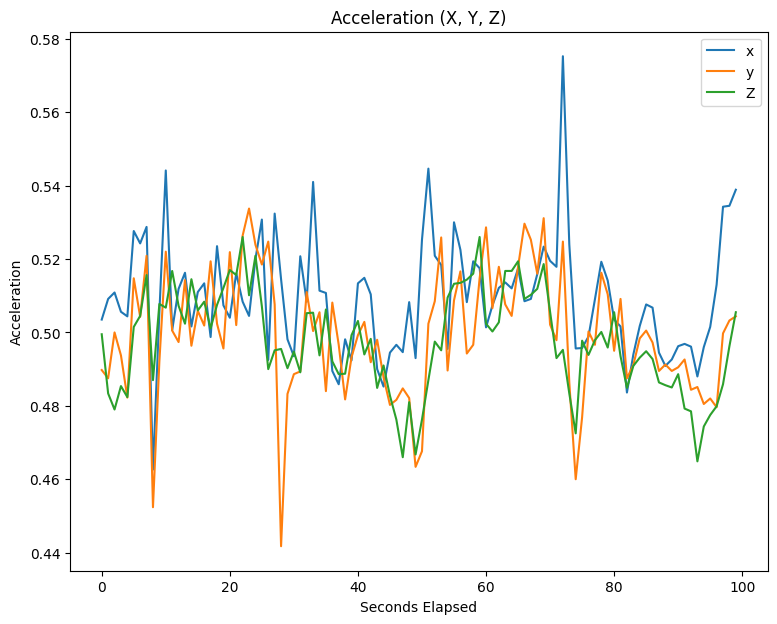

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(9, 7), sharex=True)
axes.plot(np.arange(100), data["x_accel"][20000:20100], label="x")
axes.plot(np.arange(100), data["y_accel"][20000:20100], label="y")
axes.plot(np.arange(100), data["z_accel"][20000:20100], label="Z")
axes.set_ylabel("Acceleration")
axes.set_xlabel("Seconds Elapsed")
axes.set_title("Acceleration (X, Y, Z)")
axes.legend()


In [9]:
imu_features = [
    "x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"
]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [11]:
def preprocess_sample(window, y, smooth_kernel=5, downsample_factor=1, downsample_mode="avg"):
    """
    Apply (1) moving-average smoothing along time, then (2) downsample.
    Returns (processed_window, processed_label).

    window: np.ndarray of shape (T, F)
    y: int label
    smooth_kernel: odd int window size for moving average (>=1)
    downsample_factor: e.g., 2 to keep half the samples
    downsample_mode:
        - "slice": take every k-th sample (fastest)
        - "avg": average-pool non-overlapping blocks (pads end if needed)
    """
    X = window.astype(np.float32)

    # 1) Smoothing (moving average, 'same' length)
    if smooth_kernel and smooth_kernel > 1:
        k = int(smooth_kernel)
        if k % 2 == 0:
            k += 1  # enforce odd
        kernel = np.ones(k, dtype=np.float32) / k
        # convolve each feature independently
        X = np.vstack([
            np.convolve(X[:, f], kernel, mode="same")
            for f in range(X.shape[1])
        ]).T.astype(np.float32)

    # 2) Downsample
    if downsample_factor and downsample_factor > 1:
        d = int(downsample_factor)
        if downsample_mode == "avg":
            T, F = X.shape
            # pad to make T divisible by d (repeat last row)
            pad_needed = (-T) % d
            if pad_needed:
                X = np.concatenate([X, np.repeat(X[-1:, :], pad_needed, axis=0)], axis=0)
            X = X.reshape(-1, d, F).mean(axis=1)
        else:  # "slice"
            X = X[::d]

    return X, y  # <- two values, as pediste

In [12]:
import torch
from torch.utils.data import Dataset

class IMUDataset(Dataset):
    def __init__(self, dataframes, features, window_size=300, step_size=150,
                 preprocess_fn=None, preprocess_kwargs=None):
        """
        dataframes: list of pandas DataFrames
        features: list of feature column names to use
        window_size: number of timesteps per window (e.g. 300 = 3s at 100Hz)
        step_size: overlap between windows (e.g. 150 = 50% overlap)
        """
        self.samples = []
        self.preprocess_fn = preprocess_fn
        self.preprocess_kwargs = preprocess_kwargs or {}

        for df in dataframes:
            X = df[features].values
            y = int(df["activityEncoded"].iloc[0])  # same label for the whole sequence

            for start in range(0, len(X) - window_size + 1, step_size):
                end = start + window_size
                window = X[start:end]

                if self.preprocess_fn is not None:
                    window, y_out = self.preprocess_fn(window, y, **self.preprocess_kwargs)
                    y_use = y_out
                else:
                    y_use = y

                self.samples.append((window, y_use))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        X, y = self.samples[idx]
        X = torch.tensor(X, dtype=torch.float32)  # (window_size, num_features)
        y = torch.tensor(y, dtype=torch.long)     # Class
        return X, y


In [13]:
window_size = 300                 # timesteps per window (100 ≈ 1 second at 100 Hz)
step_size = 30                   # overlap between windows ( window_size/2 = 50%)

train_split = 0.8

In [19]:
from sklearn.model_selection import train_test_split

def simple_session_split(data, train_ratio=0.8, seed=42):
    """
    Randomly splits a list of session DataFrames into train and test sets.
    This ensures no single recording session leaks across the split.
    """
    # train_test_split can handle lists directly. 
    # It will randomly shuffle the DataFrames, but keep the internal rows intact.
    train_dfs, test_dfs = train_test_split(
        data, 
        train_size=train_ratio, 
        random_state=seed, 
        shuffle=True
    )
    
    return train_dfs, test_dfs

# ---- use the splitter ----
# Assuming 'data' is your list of DataFrames, each with columns: ['x', 'y', 'z', 'label']
train_split = 0.8
train_dfs, test_dfs = simple_session_split(data, train_ratio=train_split, seed=42)

print(f"Total Sessions -> train: {len(train_dfs)} | test: {len(test_dfs)}")
#print([int(df['excercise']) for df in train_dfs])
# Quick distribution check using your new 'label' column
# This assumes the label is uniform across the entire session/DataFrame
train_labels = [int(df['excercise']) for df in train_dfs]
test_labels = [int(df['excercise']) for df in test_dfs]

print(f"Train class distribution: {train_labels.count(0)} (Class 0) | {train_labels.count(1)} (Class 1)")
print(f"Test class distribution:  {test_labels.count(0)} (Class 0) | {test_labels.count(1)} (Class 1)")


Total Sessions -> train: 254208 | test: 63553


TypeError: string indices must be integers

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader


# 2) Fit scaler ONLY on TRAIN using a DataFrame (keeps feature names, no warnings)
scaler = StandardScaler()
train_stack_df = pd.concat([df.loc[:, imu_features] for df in train_dfs], ignore_index=True)
scaler.fit(train_stack_df)   # fitted WITH feature names

# 3) Transform in place (preserve column order and names)
for df in train_dfs:
    df.loc[:, imu_features] = scaler.transform(df.loc[:, imu_features])

for df in test_dfs:
    df.loc[:, imu_features] = scaler.transform(df.loc[:, imu_features])

# (Optional) Keep the scaler for inference/production to apply the same transform:
#   - from joblib import dump, load
#   - dump(scaler, "imu_scaler.joblib")
#   - scaler = load("imu_scaler.joblib")   # later

# 4) Build datasets (one per split) from the pre-scaled DataFrames
#    IMUDataset should NOT re-normalize internally.
train_dataset = IMUDataset(  dataframes=train_dfs,
    features=imu_features,
    window_size=window_size,
    step_size=step_size,
    preprocess_fn=preprocess_sample,
    preprocess_kwargs=dict(smooth_kernel=5, downsample_factor=2, downsample_mode="avg")
)

test_dataset = IMUDataset(
    dataframes=test_dfs,
    features=imu_features,
    window_size=window_size,
    step_size=step_size,
    preprocess_fn=preprocess_sample,   # mismo preprocesado en test
    preprocess_kwargs=dict(smooth_kernel=5, downsample_factor=2, downsample_mode="avg")
)

# 5) DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1,  shuffle=False)

assert set(map(id, train_dfs)).isdisjoint(set(map(id, test_dfs))), "Leak: same session in both splits"

AttributeError: 'str' object has no attribute 'loc'

In [ ]:
print("Train dataset size:", len(train_dataset))

X, y = train_dataset[0]
print("X shape:", X.shape)   # (window_size, num_features)
print("y:", y)               # label

for X, y in train_loader:
    print("Batch X shape:", X.shape)   # (batch_size, window_size, num_features)
    print("Batch y shape:", y.shape)   # (batch_size,)
    break

#Test dataset info
print("Test dataset size:", len(test_dataset))
X, y = test_dataset[0]
print("X shape:", X.shape)   # (window_size, num_features)
print("y:", y)               # label

for X, y in test_loader:
    print("Batch X shape:", X.shape)   # (batch_size, window_size, num_features)
    print("Batch y shape:", y.shape)   # (batch_size,)
    break
    

In [ ]:
# Data parameters
num_features = len(imu_features)  # IMU feature channels (gyro, acc)
num_classes = 2 # 21

# Training parameters
learning_rate = 2e-4
num_epochs = 10

# Model parameters
hidden_dim = 64                   # LSTM hidden dimension
lstm_layers = 2                   # number of stacked LSTM layers

# Optimization / regularization
clip_grad_norm = 1.0              # gradient clipping max norm
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam

NameError: name 'torch' is not defined

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_LSTM(nn.Module):
    def __init__(self, num_features=13, num_classes=21, hidden_dim=64, lstm_layers=1):
        super(CNN_LSTM, self).__init__()

        # CNN feature extractor
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.conv3 = nn.Conv1d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn3   = nn.BatchNorm1d(128)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True
        )

        # Classifier
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = x.permute(0, 2, 1)  # (batch, features, seq_len)

        # CNN
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))  # (batch, channels, seq_len//4)
        x = F.relu(self.bn3(self.conv3(x)))

        # Prepare for LSTM
        x = x.permute(0, 2, 1)  # (batch, seq_len_reduced, channels)

        # LSTM
        lstm_out, _ = self.lstm(x)  # (batch, seq_len_reduced, hidden_dim)
        out = lstm_out[:, -1, :]    # last hidden state

        # Classifier
        out = self.fc(out)
        return out


In [ ]:
model = CNN_LSTM(num_features=num_features,
                 num_classes=num_classes,
                 hidden_dim=hidden_dim,
                 lstm_layers=lstm_layers)

criterion = loss_fn

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}\n")

for name, param in model.named_parameters():
     print(f"{name}: {param.numel()} parameters")

In [ ]:
for epoch in range(num_epochs):
    correct = 0
    total = 0
    running_loss = 0.0

    for X, y in train_loader:
        X = X.to(device)
        y = y.to(device)
        model.to(device)
        optimizer.zero_grad()
        outputs = model(X)   # (batch, num_classes)

        # Loss
        loss = criterion(outputs, y)

        # Skip batch if loss is NaN
        if torch.isnan(loss):
            print("NaN detected! Skipping batch.")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()

        # Predictions
        _, predicted = torch.max(outputs, dim=1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

    # Accuracy
    epoch_acc = 100 * correct / total if total > 0 else 0
    avg_loss = running_loss / len(train_loader)

    print(f"Epoch {epoch}: loss={avg_loss:.4f}, accuracy={epoch_acc:.2f}%")

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)
        outputs = model(X)
        preds = outputs.argmax(dim=1)

        y_true.extend(y.cpu().tolist())
        y_pred.extend(preds.cpu().tolist())

cm = confusion_matrix(y_true, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=90)
plt.show()

In [ ]:
labels_present = sorted(set(y_true) | set(y_pred))
target_names = [id_to_activity[i] if i < len(id_to_activity) else f"class_{i}" for i in labels_present]

print(classification_report(
    y_true, y_pred,
    labels=labels_present,
    target_names=target_names,
    zero_division=0
))
